In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the new dataset
df = pd.read_csv('/content/vaperader test - Sheet1 (2).csv', header=None)

# The file has a variable number of columns. We will label them all to avoid mismatch errors.
column_names = [f'col_{i}' for i in range(df.shape[1])]
df.columns = column_names

# Drop col_0, col_1 (as requested), and col_11 (which is unused and constant).
columns_to_drop = ['col_0', 'col_1', 'col_11']
# Ensure columns exist before trying to drop them
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
    print(f"Dropped columns: {existing_columns_to_drop}")

# Based on the user's request and data inspection:
# Use 'col_10' (second-to-last column before dropping col_11) as the target for binarization.
# Features will be from col_2 up to col_9.

# Recalculate column_names after dropping, to get correct indices
current_column_names = df.columns.tolist()
target_col = 'col_10' # We explicitly know col_10 is the target now

# Features are all columns except the target_col
feature_cols = [col for col in current_column_names if col != target_col]

# Clean data: convert to numeric and drop NaNs
for col in feature_cols + [target_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=feature_cols + [target_col], inplace=True)
df.rename(columns={target_col: 'label'}, inplace=True)
df.reset_index(drop=True, inplace=True)

# Display label distribution BEFORE binarization
print("\nLabel distribution before binarization:")
display(df['label'].value_counts())

# Convert continuous labels to binary for classification
# Using the median as a threshold for binarization.
median_label = df['label'].median()
df['label'] = (df['label'] > median_label).astype(int)

display(df.head())
print(f"Dataset loaded with {len(df)} rows. Features used: {feature_cols}")
print(f"Labels binarized using median ({median_label}) as threshold. Unique labels: {df['label'].unique()}")

# Define features (X) and target (y) after binarization
X = df[feature_cols].copy()
y = df['label'].copy()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nData split successfully:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train unique labels: {y_train.unique()}")
print(f"y_test unique labels: {y_test.unique()}")

Dropped columns: ['col_0', 'col_1', 'col_11']

Label distribution before binarization:


,count
label,
12.5,12
7.8,7
12.9,6
10.7,6
12.8,6
...,...
21.8,1
11.2,1
19.5,1


,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,label
0,31.0,416.0,29.08,47.00,157302.0,79427.0,1582.0,4.7,1
1,25.0,403.0,28.75,46.26,162442.0,84102.0,1566.0,5.3,1
2,29.0,412.0,28.62,46.07,169347.0,84302.0,1535.0,5.6,1
3,40.0,436.0,28.64,46.20,171075.0,82384.0,1535.0,5.5,1
4,33.0,421.0,28.69,46.40,171655.0,83563.0,1559.0,5.0,1


Dataset loaded with 393 rows. Features used: ['col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9']
Labels binarized using median (12.8) as threshold. Unique labels: [1 0]

Data split successfully:
X_train shape: (275, 8)
X_test shape: (118, 8)
y_train unique labels: [1 0]
y_test unique labels: [1 0]


### Prepare Data for Random Forest

### Data Loading: Unified Source (6 Channels)

All analyses now use `/content/vaperadar - Sheet1 (1).csv`. This dataset includes 6 feature channels and 1 label column.

In [3]:
# The definition of X, y, and data splitting has been moved to the data loading cell (4fCKop-79Z8M)
# to ensure correct order of operations after label binarization. The variables X, y, X_train, X_test,
# y_train, y_test are now defined and ready for use by subsequent model training steps.

In [4]:
# Count the occurrences of each label in the original dataset
label_counts = y.value_counts()

print("Number of rows for each label:")
display(label_counts)

Number of rows for each label:


,count
label,
0,200
1,193


### Test Model with New Data

## Training Random Forest on New Data: `Untitled spreadsheet - Sheet1.csv`

In [5]:
# This cell is now redundant as data is loaded in cell 4fCKop-79Z8M.
print("Using unified data from the initial load.")
display(df.head())

Using unified data from the initial load.


,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,label
0,31.0,416.0,29.08,47.00,157302.0,79427.0,1582.0,4.7,1
1,25.0,403.0,28.75,46.26,162442.0,84102.0,1566.0,5.3,1
2,29.0,412.0,28.62,46.07,169347.0,84302.0,1535.0,5.6,1
3,40.0,436.0,28.64,46.20,171075.0,82384.0,1535.0,5.5,1
4,33.0,421.0,28.69,46.40,171655.0,83563.0,1559.0,5.0,1


### Prepare Data for New Random Forest Model

In [6]:
# Using the unified X and y defined earlier
print(f"Unified X shape: {X.shape}")
print(f"Unified y shape: {y.shape}")

# The training and testing sets (X_train, X_test, y_train, y_test) are already prepared.
print("Training and testing sets are ready.")

Unified X shape: (393, 8)
Unified y shape: (393,)
Training and testing sets are ready.


In [7]:
# retrain Random Forest
rf_model = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest trained on 6-channel data.")

Random Forest trained on 6-channel data.


In [8]:
# Evaluate the Random Forest model using the 6-channel test set
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy (6 Channels): {accuracy_rf:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy (6 Channels): 0.8136

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81        58
           1       0.83      0.80      0.81        60

    accuracy                           0.81       118
   macro avg       0.81      0.81      0.81       118
weighted avg       0.81      0.81      0.81       118



In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# For K-Means, we typically don't use the 'label' during clustering
# Let's assume we want to find 2 clusters (similar to the binary labels)
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')

# Fit K-Means to the features of the new data, ensuring features are float type
kmeans.fit(X.astype(float))

# Get the cluster labels for each data point
clusters = kmeans.labels_
df['kmeans_cluster'] = clusters

print("K-Means clustering performed. Here are the cluster counts:")
display(df['kmeans_cluster'].value_counts())

K-Means clustering performed. Here are the cluster counts:


,count
kmeans_cluster,
0,238
1,155


### Visualize K-Means Clusters (using first two features for 2D plot)

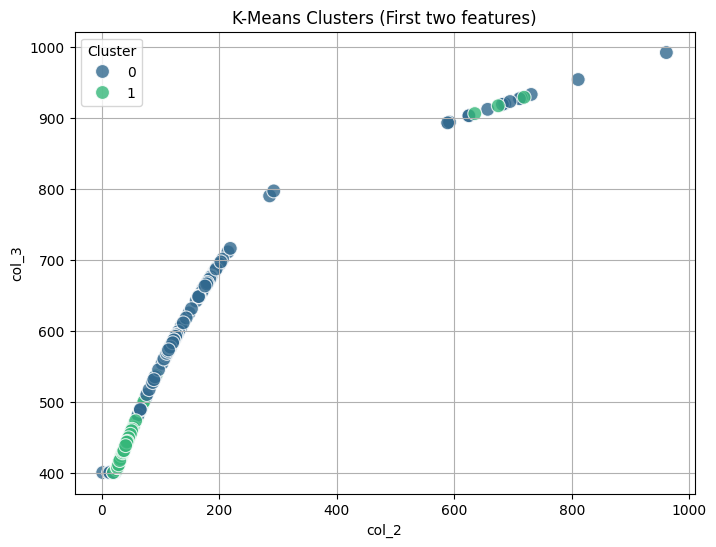

In [10]:
# For visualization, we'll use the first two features to create a 2D plot.
# If you have more than 2-3 features, you might consider dimensionality reduction (e.g., PCA) for better visualization.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df[feature_cols[0]], y=df[feature_cols[1]], hue='kmeans_cluster', data=df, palette='viridis', s=100, alpha=0.8)
plt.title('K-Means Clusters (First two features)')
plt.xlabel(feature_cols[0])
plt.ylabel(feature_cols[1])
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [11]:
# retrain KNN
knn_model = KNeighborsClassifier(n_neighbors=15)
knn_model.fit(X_train, y_train)
print("KNN trained on 6-channel data.")

KNN trained on 6-channel data.


In [12]:
# Map K-Means clusters to actual labels (0 or 1) for evaluation
# We need to decide which cluster corresponds to '0' and which to '1'

# Calculate the mean of the original 'label' for each K-Means cluster
cluster_label_means = df.groupby('kmeans_cluster')['label'].mean()

# If cluster 0 has a higher mean label, it likely corresponds to '1', otherwise '0'
# This assumes '1' is the 'positive' class you are interested in
if cluster_label_means[0] > cluster_label_means[1]:
    # Cluster 0 aligns with actual label 1, Cluster 1 aligns with actual label 0
    kmeans_to_label_map = {0: 1, 1: 0}
else:
    # Cluster 0 aligns with actual label 0, Cluster 1 aligns with actual label 1
    kmeans_to_label_map = {0: 0, 1: 1}

# Create a 'predicted' label for K-Means based on this mapping
df['kmeans_predicted_label'] = df['kmeans_cluster'].map(kmeans_to_label_map)

print("K-Means Cluster to Actual Label Mapping:", kmeans_to_label_map)
print("\nClassification-like Report for K-Means Clusters:")
print(classification_report(df['label'], df['kmeans_predicted_label']))


K-Means Cluster to Actual Label Mapping: {0: 1, 1: 0}

Classification-like Report for K-Means Clusters:
              precision    recall  f1-score   support

           0       0.54      0.42      0.47       200
           1       0.51      0.63      0.57       193

    accuracy                           0.52       393
   macro avg       0.53      0.53      0.52       393
weighted avg       0.53      0.52      0.52       393



In [13]:
# Evaluate the KNN model using the 6-channel test set
y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy (6 Channels): {accuracy_knn:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Accuracy (6 Channels): 0.6780

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.64      0.66        58
           1       0.67      0.72      0.69        60

    accuracy                           0.68       118
   macro avg       0.68      0.68      0.68       118
weighted avg       0.68      0.68      0.68       118



## Download and Test Models

In [14]:
import joblib

# Save the unified models
joblib.dump(rf_model, 'rf_model_unified.joblib')
joblib.dump(knn_model, 'knn_model_unified.joblib')

print("Unified models saved successfully!")

Unified models saved successfully!


In [15]:
import joblib
from sklearn.metrics import accuracy_score

# Load and test the unified models
loaded_rf = joblib.load('rf_model_unified.joblib')
loaded_knn = joblib.load('knn_model_unified.joblib')

rf_acc = accuracy_score(y_test, loaded_rf.predict(X_test))
knn_acc = accuracy_score(y_test, loaded_knn.predict(X_test))

print(f"Unified RF Accuracy: {rf_acc:.4f}")
print(f"Unified KNN Accuracy: {knn_acc:.4f}")

Unified RF Accuracy: 0.8136
Unified KNN Accuracy: 0.6780


## Model Performance Comparison

Comparing the Accuracy, Recall, and F1-Score of all supervised models.

In [16]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support

rf_metrics = precision_recall_fscore_support(y_test, y_pred_rf, average='weighted')
knn_metrics = precision_recall_fscore_support(y_test, y_pred_knn, average='weighted')

comparison_data = {
    'Model': ['Random Forest (6Ch)', 'KNN (6Ch)'],
    'Accuracy': [accuracy_rf, accuracy_knn],
    'Recall (Weighted)': [rf_metrics[1], knn_metrics[1]],
    'F1-Score (Weighted)': [rf_metrics[2], knn_metrics[2]]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Model,Accuracy,Recall (Weighted),F1-Score (Weighted)
0,Random Forest (6Ch),0.813559,0.813559,0.813559
1,KNN (6Ch),0.677966,0.677966,0.677410


### Confusion Matrices for Model Comparison

In [17]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix for Random Forest:")
display(pd.DataFrame(cm_rf, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Confusion Matrix for K-Nearest Neighbors
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix for K-Nearest Neighbors:")
display(pd.DataFrame(cm_knn, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

Confusion Matrix for Random Forest:


,Predicted 0,Predicted 1
Actual 0,48,10
Actual 1,12,48



Confusion Matrix for K-Nearest Neighbors:


,Predicted 0,Predicted 1
Actual 0,37,21
Actual 1,17,43


### Retraining Random Forest for 2D Visualization

In [18]:
# Select only the first two features for training a new 2D model
feature1 = feature_cols[0]
feature2 = feature_cols[1]

X_train_2d = X_train[[feature1, feature2]]
X_test_2d = X_test[[feature1, feature2]]

# Train a new Random Forest model specifically for these two features
from sklearn.ensemble import RandomForestClassifier
rf_model_2d = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_model_2d.fit(X_train_2d, y_train)
print(f"Random Forest model trained on 2 features: {feature1}, {feature2}")

Random Forest model trained on 2 features: col_2, col_3


### Random Forest Predictions (2D Plot using first two features)

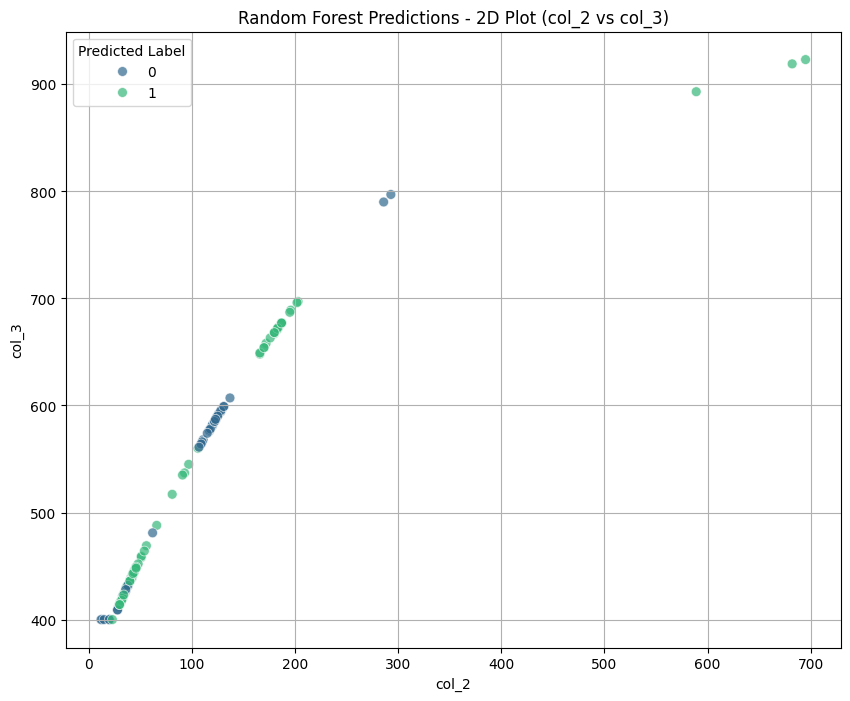

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set using the newly trained 2D Random Forest model
y_pred_rf_2d = rf_model_2d.predict(X_test_2d)

# Create a DataFrame for plotting
plot_df_rf = X_test_2d.copy()
plot_df_rf['predicted_label'] = y_pred_rf_2d
plot_df_rf['actual_label'] = y_test.values

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=feature1,
    y=feature2,
    hue='predicted_label',
    data=plot_df_rf,
    palette='viridis',
    s=50, # size of points
    alpha=0.7 # transparency
)

plt.title(f'Random Forest Predictions - 2D Plot ({feature1} vs {feature2})')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.legend(title='Predicted Label')
plt.grid(True)
plt.show()

In [26]:
!git config --global user.email "Nasuda.earn29@gmail.com"
!git config --global user.name "earn438"

In [27]:
%cd /content

/content


In [28]:
!git init

Reinitialized existing Git repository in /content/.git/


In [29]:
!git add .

In [30]:
!git commit -m "Initial commit - VapeRadar01"

[master (root-commit) 8d1c03c] Initial commit - VapeRadar01
 24 files changed, 51453 insertions(+)
 create mode 100644 .config/.last_opt_in_prompt.yaml
 create mode 100644 .config/.last_survey_prompt.yaml
 create mode 100644 .config/.last_update_check.json
 create mode 100644 .config/active_config
 create mode 100644 .config/config_sentinel
 create mode 100644 .config/configurations/config_default
 create mode 100644 .config/default_configs.db
 create mode 100644 .config/gce
 create mode 100644 .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
 create mode 100644 .config/logs/2026.06.04/13.38.54.010366.log
 create mode 100644 .config/logs/2026.06.04/13.39.12.467650.log
 create mode 100644 .config/logs/2026.06.04/13.39.22.644527.log
 create mode 100644 .config/logs/2026.06.04/13.39.24.274402.log
 create mode 100644 .config/logs/2026.06.04/13.39.36.079406.log
 create mode 100644 .config/logs/2026.06.04/13.39.37.138439.log
 create mode 100644 knn_model_unified.joblib


In [31]:
!git remote add origin https://github.com/earn438/VapeRadar01

In [32]:
!git branch -M main
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [34]:
!git remote set-url origin https://YOUR_TOKEN@github.com/earn438/VapeRadar01.git

In [35]:
!git push -u origin main

fatal: unable to access 'https://YOUR_TOKEN@github.com/earn438/VapeRadar01.git/': Could not resolve host: YOUR_TOKEN_HERE


In [38]:
!git remote set-url origin https://YOUR_TOKEN_HERE/earn438/VapeRadar01.git

In [39]:
!git push -u origin main

fatal: unable to access 'https://YOUR_TOKEN_HERE/earn438/VapeRadar01.git/': Could not resolve host: YOUR_TOKEN_HERE


In [40]:
!git remote set-url origin https://YOUR_TOKEN_HERE@github.com/earn438/VapeRadar01.git

In [41]:
!git push -u origin main

Enumerating objects: 31, done.
Counting objects: 100% (31/31), done.
Delta compression using up to 2 threads
Compressing objects: 100% (24/24), done.
Writing objects: 100% (31/31), 9.39 MiB | 2.71 MiB/s, done.
Total 31 (delta 6), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (6/6), done.
To https://github.com/earn438/VapeRadar01.git
 * [new branch]      main -> main
Branch 'main' set up to track remote branch 'main' from 'origin'.
